In [2]:
import numpy as np
import torch.nn as nn

In [3]:
class TwoLayerNet:
    def __init__(self, input_dim, hidden_dim, n_classes):
        self.W1 = np.random.randn((input_dim,hidden_dim))
        self.b1 = np.random.randn(input_dim)
        self.W2 = np.random.randn((hidden_dim,n_classes))
        self.b2 = np.random.randn(input_dim)

    def forward(self, X):
        self.Z_first = self.W1@X + self.b1
        self.relu_first = np.maximum(self.Z_first)
        scores = self.relu_first @ self.W2 + self.b2
        cache = {}

        cache['X'] = X
        cache['relu_first'] = self.relu_first


        return scores, cache

    def predict(self, X):
        scores, _ = self.forward(X)
        return scores.argmax(axis=1)

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt

SEED = 7
np.set_printoptions(precision=4, suppress=True)

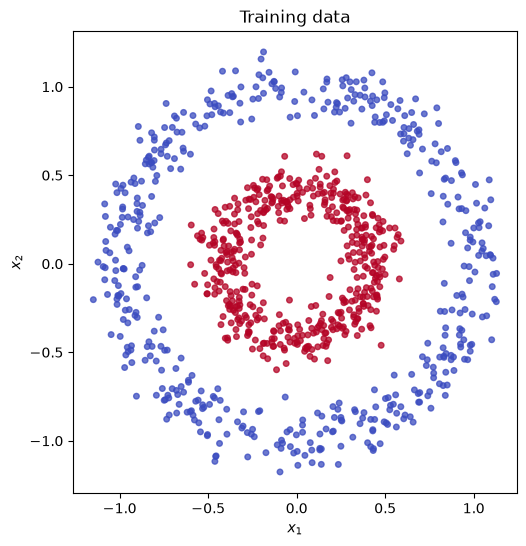

In [5]:
def make_circles(n_samples=1200, noise=0.08, factor=0.42, seed=SEED):
    rng = np.random.default_rng(seed)
    n_inner = n_samples // 2
    n_outer = n_samples - n_inner
    a_outer = rng.uniform(0, 2*np.pi, n_outer)
    a_inner = rng.uniform(0, 2*np.pi, n_inner)
    outer = np.c_[np.cos(a_outer), np.sin(a_outer)]
    inner = factor * np.c_[np.cos(a_inner), np.sin(a_inner)]
    X = np.vstack([outer, inner]) + rng.normal(0, noise, (n_samples, 2))
    y = np.r_[np.zeros(n_outer), np.ones(n_inner)].reshape(-1, 1)
    order = rng.permutation(n_samples)
    return X[order], y[order]

X, y = make_circles()
cut = int(0.8 * len(X))
X_train, y_train = X[:cut], y[:cut]
X_val, y_val = X[cut:], y[cut:]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train[:, 0], cmap='coolwarm', s=16, alpha=.75)
ax.set(title='Training data', xlabel='$x_1$', ylabel='$x_2$', aspect='equal');

Because here it is not a linear problem, so with just a linear model ,the acccuracy will not be low and not efficient

In [ ]:
class OneHiddenNet:
    def __init__(self, input_dim, hidden_dim, seed=SEED):
        # TODO 1: initialize W1, b1, W2, b2 with correct shapes.
        # Use rng = np.random.default_rng(seed) and scale weights by sqrt(1/fan_in).
        self.W1 = np.random.randn(input_dim, hidden_dim) 
        self.b1 = np.ramdon.rand(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, 1) * np.sqrt(1 / hidden_dim)
        self.b2 = np.ramdon.randn(1)
        

    def forward(self, X):
        # TODO 2: compute z1, h1, z2, probabilities and return (probabilities, cache).
        # Use a numerically stable sigmoid expression by clipping z2 to [-500, 500].
        self.z1 = X @ self.W1 + self.b1
        self.h1 = np.maximum(self.z1, 0)
        self.z2 = self.h1 @ self.W2 + self.b2
        probabilities = 1 / (1 + np.exp(-z2,))
        cache = {}
        cache['X'] = X
        cache['h1'] = self.h1
        return probabilities, cache

    def predict(self, X):
        # TODO 3: threshold the probabilities and return a 1-D integer array.
        probabilities